# 1. Imports and data load

In [11]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

In [19]:
X = pd.read_csv("../data/processed/Features_Solar.csv")

X.head()

,Date,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear
0,2017-01-02T00:00:00.000000,1.2,0.0,1013.6,-7.6,61,0,1,2
1,2017-01-02T01:00:00.000000,1.1,0.0,1013.3,-7.3,65,1,1,2
2,2017-01-02T02:00:00.000000,1.0,0.0,1013.3,-6.9,66,2,1,2
3,2017-01-02T03:00:00.000000,0.7,0.0,1013.4,-6.8,66,3,1,2
4,2017-01-02T04:00:00.000000,1.4,0.0,1013.2,-7.4,62,4,1,2


In [20]:
preds = pd.read_csv("../data/results/Predicciones_Solar.csv")

preds.head()

,Date,SystemProduction_AS
0,2017-01-02T00:00:00.000000,1.348889
1,2017-01-02T01:00:00.000000,0.000000
2,2017-01-02T02:00:00.000000,0.000000
3,2017-01-02T03:00:00.000000,0.000000
4,2017-01-02T04:00:00.000000,0.000000


In [21]:
X_analysis = X.copy()

X_analysis["PredictedProduction"] = preds["SystemProduction_AS"]

In [22]:
X_analysis.head()

,Date,WindSpeed,Sunshine,AirPressure,Radiation,RelativeAirHumidity,hour,dayofweek,dayofyear,PredictedProduction
0,2017-01-02T00:00:00.000000,1.2,0.0,1013.6,-7.6,61,0,1,2,1.348889
1,2017-01-02T01:00:00.000000,1.1,0.0,1013.3,-7.3,65,1,1,2,0.000000
2,2017-01-02T02:00:00.000000,1.0,0.0,1013.3,-6.9,66,2,1,2,0.000000
3,2017-01-02T03:00:00.000000,0.7,0.0,1013.4,-6.8,66,3,1,2,0.000000
4,2017-01-02T04:00:00.000000,1.4,0.0,1013.2,-7.4,62,4,1,2,0.000000


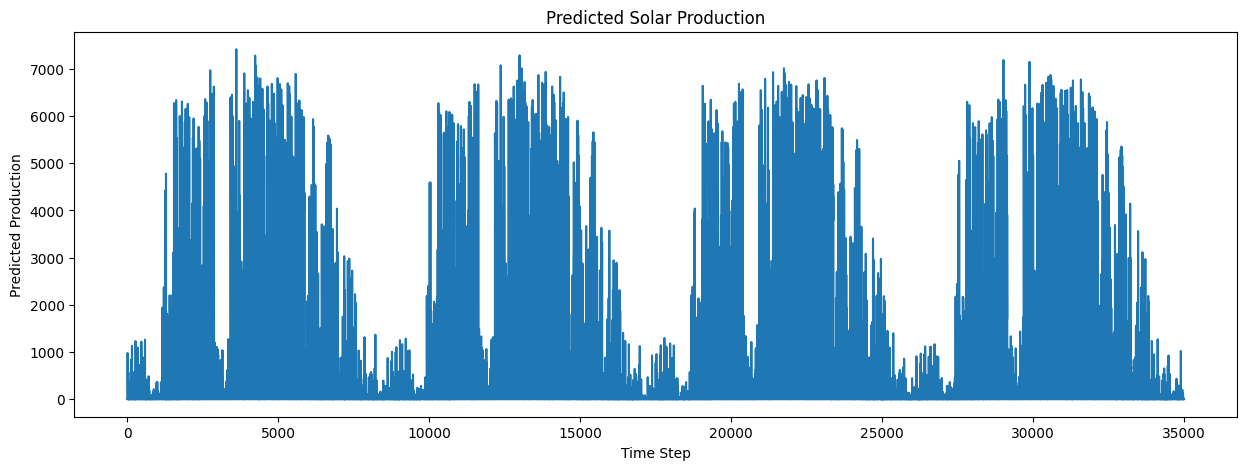

In [23]:
plt.figure(figsize=(15,5))

plt.plot(X_analysis["PredictedProduction"])

plt.title("Predicted Solar Production")
plt.xlabel("Time Step")
plt.ylabel("Predicted Production")

plt.show()

In [24]:
X_analysis["PredictedProduction"].describe()

count    35016.000000
mean       684.910311
std       1404.385688
min          0.000000
25%          0.080100
50%          7.795061
75%        545.290155
max       7418.060974
Name: PredictedProduction, dtype: float64

# 2. Model load

In [26]:
model = joblib.load("../models/modelo_solar.pkl")

X_model = X.drop(columns=["Date"])

print(model.n_estimators)
print(X_model.columns.tolist())

c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


300
['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'RelativeAirHumidity', 'hour', 'dayofweek', 'dayofyear']


c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 3. Feature Importance (Random Forest Internal Importance)

In [27]:
rf_importance = pd.DataFrame({
    "Feature": X_model.columns,
    "Importance": model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
3,Radiation,0.359258
1,Sunshine,0.169679
5,hour,0.150036
4,RelativeAirHumidity,0.126117
7,dayofyear,0.121321
0,WindSpeed,0.043920
2,AirPressure,0.021769
6,dayofweek,0.007900


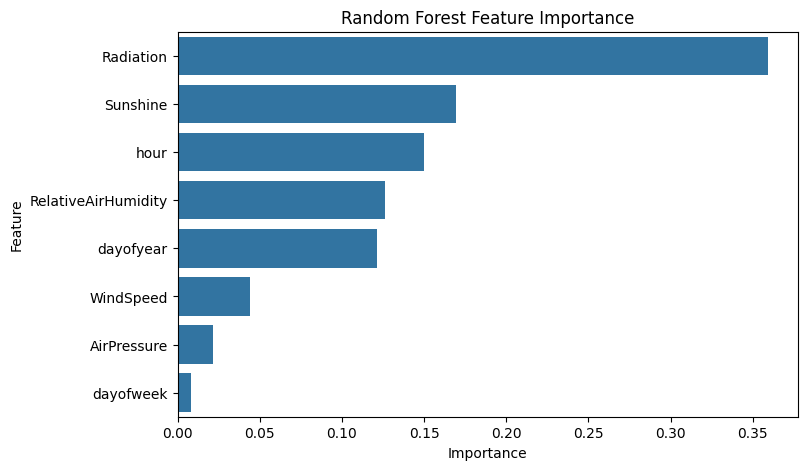

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance Analysis

The Random Forest feature importance analysis reveals that solar radiation is the most influential variable, accounting for approximately 36% of the model's total importance. This result is consistent with the physical principles of photovoltaic energy generation, where incoming solar radiation directly determines the amount of electricity produced.

Sunshine duration and hour of the day are the second and third most important features, indicating that the model captures both meteorological conditions and daily solar production patterns. Relative humidity and day of the year also contribute significantly, suggesting that the model incorporates seasonal and atmospheric effects into its predictions.

In contrast, wind speed and air pressure have a relatively small influence on the forecasts, while the day of the week contributes negligibly. This behaviour is expected since photovoltaic generation depends primarily on environmental conditions rather than calendar-related variables.

Overall, the feature importance ranking demonstrates that the model relies on physically meaningful predictors, increasing confidence in its use within the microgrid environment.


# 4. PDP

## RADIATION

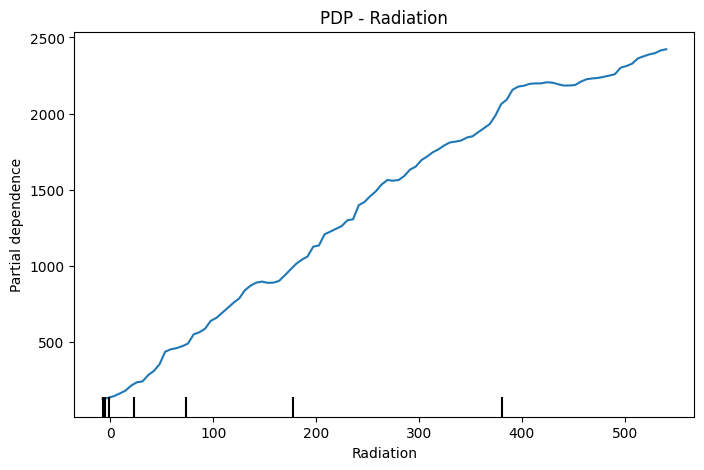

In [29]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["Radiation"],
    ax=ax
)

plt.title("PDP - Radiation")
plt.show()

### Partial Dependence Plot for Radiation

The Partial Dependence Plot (PDP) for solar radiation reveals a strong positive relationship between radiation levels and the predicted photovoltaic power output. As radiation increases, the model consistently predicts higher energy generation, confirming that solar radiation is the primary driver of the forecasting model.

The relationship is not strictly linear. The slope of the curve varies across different radiation levels, indicating that the Random Forest captures complex and nonlinear dependencies between solar radiation and energy production. This behaviour is expected in photovoltaic systems, where the conversion of solar energy into electricity may not increase proportionally across the entire operating range.

A slight flattening of the curve can be observed at high radiation values, suggesting a potential saturation effect where additional increases in radiation produce smaller increments in the predicted power output.

Overall, the PDP confirms that the model has learned physically meaningful relationships and relies heavily on solar radiation when estimating photovoltaic generation.


## SUNSHINE

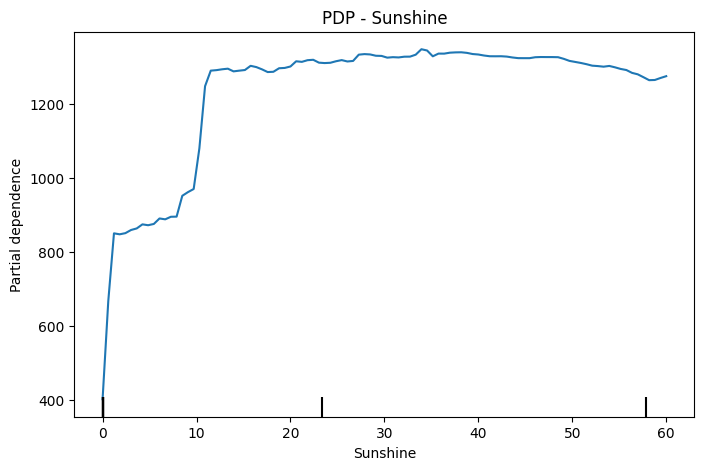

In [30]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["Sunshine"],
    ax=ax
)

plt.title("PDP - Sunshine")
plt.show()

### Partial Dependence Plot for Sunshine

The Partial Dependence Plot for sunshine reveals a positive but nonlinear relationship with the predicted photovoltaic power output. The model shows a substantial increase in generation when sunshine values rise from very low levels, indicating that the presence of sunlight is a critical factor for solar energy production.

A second noticeable increase occurs around moderate sunshine values, suggesting the existence of threshold effects captured by the Random Forest model. Beyond this point, the curve becomes relatively stable, indicating that additional sunshine contributes less significantly to further increases in predicted generation.

Compared with solar radiation, sunshine exhibits a less continuous influence on the forecasts. While radiation drives a gradual increase in power output across its entire range, sunshine appears to affect the predictions mainly through threshold-based behaviour.

These results suggest that the model uses sunshine as a complementary indicator of favourable solar conditions while relying primarily on radiation to estimate the magnitude of photovoltaic generation.


## HOUR

c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 5 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


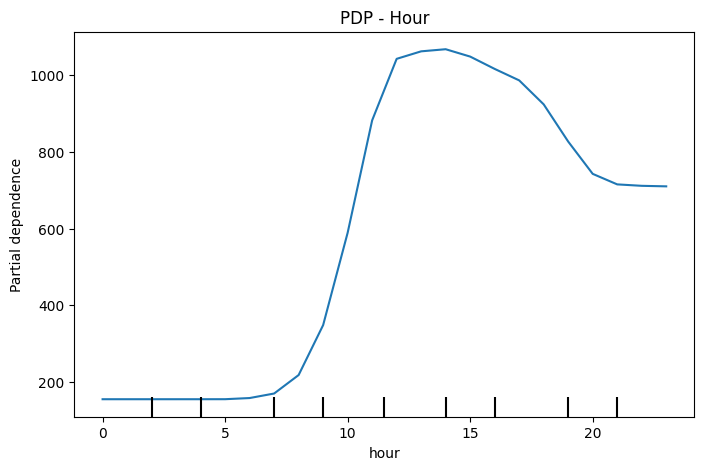

In [31]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=["hour"],
    ax=ax
)

plt.title("PDP - Hour")
plt.show()

### Partial Dependence Plot for Hour

The Partial Dependence Plot for the hour of the day reveals a clear daily production pattern learned by the Random Forest model. Predicted photovoltaic generation remains low during nighttime hours and increases rapidly during the morning, reaching its maximum around midday and early afternoon.

The steep increase observed between approximately 09:00 and 13:00 reflects the growing availability of solar energy throughout the day. After the peak period, the predicted generation gradually decreases, capturing the typical decline in solar irradiance during the afternoon.

This behaviour demonstrates that the model successfully incorporates temporal information and reproduces realistic photovoltaic generation cycles. The results also highlight the importance of including temporal features alongside meteorological variables when forecasting solar power production.


# 5. FEATURE INTERACTION

c:\Users\User\Documents\GitHub\Reto04_Grupo05\.venv\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 5 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


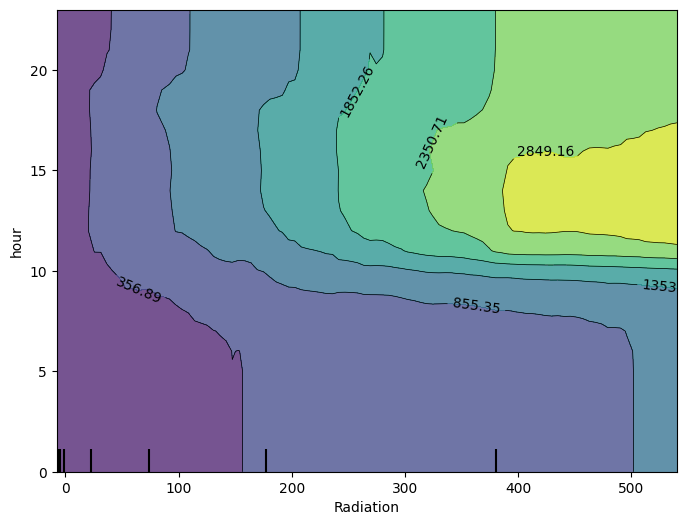

In [32]:
fig, ax = plt.subplots(figsize=(8,6))

PartialDependenceDisplay.from_estimator(
    model,
    X_model,
    features=[("Radiation", "hour")],
    ax=ax
)

plt.show()

## Feature Interaction Analysis: Radiation and Hour

The interaction analysis between solar radiation and hour of the day reveals a strong dependency between both variables. The influence of radiation on photovoltaic generation is not constant across all hours but varies significantly throughout the day.

At low radiation levels, predicted production remains relatively low regardless of the hour. However, as radiation increases, the impact on the forecast becomes substantially stronger during daylight and peak solar hours. The highest predicted generation values are observed when high radiation levels coincide with midday and early afternoon periods.

The contour patterns indicate the presence of a meaningful interaction effect, demonstrating that the contribution of radiation depends on the temporal context in which it occurs. This behaviour is physically consistent with photovoltaic systems, where both the amount of incoming radiation and the position of the sun jointly determine the electricity production.

The results confirm that the Random Forest model captures realistic relationships between meteorological and temporal variables, increasing confidence in its deployment within the microgrid environment.


# 6. ALE